# Week 3 — Mastering GeoPandas in Jupyter (Student Worksheet)
**Course:** Remote Sensing & Spatial Information Analysis and Application (114)  
**Instructor:** Prof. Wen-Rui Su · NCDR / NTU Civil Engineering  

## How to use this Notebook

| Section | Style | What you do |
|---------|-------|-------------|
| Cell [1]–[4] | **Fill-in-the-blank** | Code is mostly written; fill in the `____` blanks |
| Cell [5]–[8] | **AI-collaborative** | Copy the prompt to Windsurf/AI, paste the generated code here, then run & verify |
| Lab 1 & Lab 2 | **AI-collaborative** | Same as above — prompt AI, paste, run, inspect |

> The goal is NOT to memorize syntax — it's to **understand what each step does** and **verify AI output**.

### Data Source
Township boundaries: [內政部國土測繪中心 — 鄉鎮市區界線 (TWD97)](https://data.gov.tw/dataset/7441)  
Direct download via [TGOS](https://www.tgos.tw/)

---
# Phase 1: Fill-in-the-Blank (Cell [1]–[4])
*Read the slide, then fill in the blanks (`____`) in the code below.*

## Cell [1] — Environment Setup
*Slide 2 · The "Glass Box" Philosophy*

Import the core libraries we need for spatial analysis.

> **Before you start:** Make sure you have installed all required packages (see Pre-lab).  
> If `.explore()` fails later, run this in a **new cell**:
> ```python
> !pip install folium mapclassify osmnx
> ```
> Then **restart the kernel** (Kernel → Restart).

In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from urllib.parse import quote #url encode

# Check version
print(f'geopandas {gpd.__version__} ✓')      # Hint: gpd.__version__
print('All imports OK — Glass Box is ready!')

geopandas 0.13.2 ✓
All imports OK — Glass Box is ready!


## Cell [2] — Load Taiwan Township Boundaries
*Slide 4 · Anatomy of a GeoDataFrame (GDF)*

Read township boundaries directly from **TGOS** — no manual download needed.

In [7]:
# --- Read directly from TGOS (run as-is, no blanks) ---
# This zip has 2 layers — we need layer 1 (all 368 townships)
TGOS_BASE = 'https://www.tgos.tw/tgos/VirtualDir/Product/3fe61d4a-ca23-4f45-8aca-4a536f40f290/'
FILENAME  = '鄉(鎮、市、區)界線1140318.zip'
url = TGOS_BASE + quote(FILENAME)

print(url)
print('Reading township boundaries from TGOS ...')
townships = gpd.read_file(url, layer='TOWN_MOI_1140318')
print('Done!')

https://www.tgos.tw/tgos/VirtualDir/Product/3fe61d4a-ca23-4f45-8aca-4a536f40f290/%E9%84%89%28%E9%8E%AE%E3%80%81%E5%B8%82%E3%80%81%E5%8D%80%29%E7%95%8C%E7%B7%9A1140318.zip
Reading township boundaries from TGOS ...
Done!


In [3]:
# --- Fill in the blanks ---
print('Shape:', townships.shape)      # How many rows × columns?
print('CRS  :', townships.crs)      # What coordinate system?
print()
townships.head()

Shape: (368, 8)
CRS  : GEOGCS["GCS_TWD97[2020]",DATUM["Taiwan_Datum_1997",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","1026"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AXIS["Longitude",EAST],AXIS["Latitude",NORTH]]



,TOWNID,TOWNCODE,COUNTYNAME,TOWNNAME,TOWNENG,COUNTYID,COUNTYCODE,geometry
0,V02,10014020,臺東縣,成功鎮,Chenggong Township,V,10014,"POLYGON ((121.36149 23.22900, 121.36219 23.228..."
1,T21,10013210,屏東縣,佳冬鄉,Jiadong Township,T,10013,"POLYGON ((120.54845 22.46067, 120.54853 22.460..."
2,P13,10009130,雲林縣,麥寮鄉,Mailiao Township,P,10009,"POLYGON ((120.30198 23.81624, 120.30198 23.815..."
3,V11,10014110,臺東縣,綠島鄉,Lüdao Township,V,10014,"MULTIPOLYGON (((121.49154 22.67746, 121.49184 ..."
4,V16,10014160,臺東縣,蘭嶼鄉,Lanyu Township,V,10014,"MULTIPOLYGON (((121.61179 21.94290, 121.61133 ..."


In [ ]:
# Inspect the geometry column — what type of shapes are stored?
townships.geometry.head()           # Hint: the column that holds spatial data
                                    #.head() 顯示前5筆資料

0    POLYGON ((121.36149 23.22900, 121.36219 23.228...
1    POLYGON ((120.54845 22.46067, 120.54853 22.460...
2    POLYGON ((120.30198 23.81624, 120.30198 23.815...
3    MULTIPOLYGON (((121.49154 22.67746, 121.49184 ...
4    MULTIPOLYGON (((121.61179 21.94290, 121.61133 ...
Name: geometry, dtype: geometry

## Cell [3] — Reprojection: CRS Transformation
*Slide 6 · GeoPandas Power 1: Reprojection*

Create a point for NTU Civil Engineering, then **reproject** from degrees to meters.

In [11]:
# Create a GeoDataFrame with one point (NTU Civil Eng.)
ntu_point = gpd.GeoDataFrame(
    {'name': ['NTU Civil Eng.']},
    geometry=gpd.points_from_xy([121.5413], [25.0174]),
    crs='EPSG:4326'                    # Hint: WGS84 = ?
)

print('Before reprojection (WGS84, degrees):')
print(ntu_point.geometry.values)

# Reproject to TWD97 / TM2 zone 2 (meters)
ntu_twd97 = ntu_point.to_crs(epsg=3826)  # Hint: Taiwan's projected CRS

print('\nAfter reprojection (TWD97, meters):')
print(ntu_twd97.geometry.values[0])

# Also reproject townships for later use
townships_3826 = townships.to_crs(epsg=3826)


Before reprojection (WGS84, degrees):
<GeometryArray>
[<POINT (121.541 25.017)>]
Length: 1, dtype: geometry

After reprojection (TWD97, meters):
POINT (304631.64772700093 2767813.957698129)


## Cell [4] — Geometric Properties
*Slide 7 · GeoPandas Power 2: Geometric Properties*

Calculate `.area` for Taiwan's townships. Watch the CRS difference!

In [ ]:
# Area in EPSG:4326 — meaningless "square degrees"
townships['area_4326'] = townships.area # 得到的是 平方度(square degrees)不是實際面積，沒有地理意義。

# Area in EPSG:3826 — correct, in square meters
townships_3826['area_m2'] = townships_3826.area
townships_3826['area_km2'] = townships_3826['area_m2'] / 1000000  # How many m² in 1 km²?

print('Top 10 largest townships by area (km²):')
print(townships_3826.nlargest(10, 'area_km2')[['COUNTYNAME', 'TOWNNAME', 'area_km2']].to_string(index=False))
 # nlargest 找出某欄位 數值最大的 N 筆資料
 

0    0.012900
1    0.002836
2    0.011107
3    0.001252
4    0.004137
Name: area_4326, dtype: float64
0    1.463061e+08
1    3.232435e+07
2    1.253680e+08
3    1.425002e+07
4    4.727822e+07
Name: area_m2, dtype: float64
Top 10 largest townships by area (km²):
COUNTYNAME TOWNNAME    area_km2
       花蓮縣      秀林鄉 1621.993984
       南投縣      信義鄉 1423.746510
       南投縣      仁愛鄉 1220.322437
       花蓮縣      卓溪鄉 1045.073566
       臺中市      和平區 1007.744574
       高雄市      桃源區  975.433482
       臺東縣      海端鄉  892.992139
       宜蘭縣      大同鄉  770.031776
       宜蘭縣      南澳鄉  712.525599
       花蓮縣      萬榮鄉  659.024578


C:\Users\vicky\AppData\Local\Temp\ipykernel_10928\664832996.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  townships['area_4326'] = townships.area  # Hint: geometric property for area


---
# Phase 2: AI-Collaborative (Cell [5]–[8])
*Copy the **Prompt** to Windsurf / ChatGPT / Claude → paste the AI-generated code → Run → Verify the result.*

> **Your job is to CHECK the AI's work**, not just trust it!

## Cell [5] — The Buffer Zone
*Slide 8 · GeoPandas Power 3: The Buffer Zone*

**Prompt to give AI:**
```
I have two GeoDataFrames:
- ntu_point (EPSG:4326, a single point at lon=121.5413, lat=25.0174)
- ntu_twd97 (EPSG:3826, same point reprojected to meters)

Please create a 500-unit buffer for BOTH and print:
1. The bounds of each buffer
2. The area of the correct (meter-based) buffer
Show me why the EPSG:4326 buffer is wrong.
```

**After running, verify:**  
- Does the EPSG:4326 buffer have absurdly large bounds?  
- Is the EPSG:3826 buffer area close to π × 500² ≈ 785,398 m²?

In [ ]:
# Paste AI-generated code below, then run this cell

buffer_4326 = ntu_point.buffer(500)
buffer_3826 = ntu_twd97.buffer(500)

print("EPSG:4326 buffer bounds:")
print(buffer_4326.bounds)

print("\nEPSG:3826 buffer bounds:")
print(buffer_3826.bounds)

# Print correct area
print("\nArea of EPSG:3826 buffer (m^2):")
print(buffer_3826.area)

EPSG:4326 buffer bounds:
       minx      miny      maxx      maxy
0 -378.4587 -474.9826  621.5413  525.0174

EPSG:3826 buffer bounds:
            minx          miny           maxx          maxy
0  304131.647727  2.767314e+06  305131.647727  2.768314e+06

Area of EPSG:3826 buffer (m^2):
0    784137.122636
dtype: float64

Area of EPSG:4326 buffer (m^2):
0    784137.122636
dtype: float64
EPSG:3826


C:\Users\vicky\AppData\Local\Temp\ipykernel_10928\1166450735.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  buffer_4326 = ntu_point.buffer(500)
C:\Users\vicky\AppData\Local\Temp\ipykernel_10928\1166450735.py:16: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  print(buffer_4326.area)


## Cell [6] — Spatial Join (sjoin)
*Slide 10 · Spatial Join: The Ultimate Superpower*

**Prompt to give AI:**
```
Using GeoPandas, help me:
1. Get the NTU TWD97 center coordinates from the variable ntu_twd97
   (ntu_twd97.geometry.x[0] and .y[0])
2. Create 10 random shelter points around NTU area in EPSG:3826
   (within ±400m of the center point, use np.random.seed(42))
3. Create a GeoDataFrame for a 500m buffer zone
   (use the variable buf_correct from Cell [5])
4. Run gpd.sjoin() to find which shelters fall WITHIN the buffer
5. Print how many shelters are inside
```

**After running, verify:**  
- Do both GeoDataFrames have the **same CRS** before sjoin?  
- Is the result count ≤ total shelter count?  
- Do the shelters INSIDE the buffer make spatial sense? (±400m range, 500m radius → most should be inside)

In [ ]:
# Paste AI-generated code below, then run this cell

cx = ntu_twd97.geometry.x[0]
cy = ntu_twd97.geometry.y[0]
print("NTU center (TWD97):", cx, cy)

NTU center (TWD97): 304631.64772700093 2767813.957698129


In [24]:

import numpy as np
from shapely.geometry import Point

np.random.seed(42)

x_rand = cx + np.random.uniform(-400, 400, 10)
y_rand = cy + np.random.uniform(-400, 400, 10)

shelter_points = [Point(x, y) for x, y in zip(x_rand, y_rand)]
shelters_random = gpd.GeoDataFrame({'name': [f'Shelter_{i}' for i in range(10)], 
    'geometry': shelter_points}, crs='EPSG:3826')
print(shelters_random)

        name                        geometry
0  Shelter_0  POINT (304531.280 2767430.425)
1  Shelter_1  POINT (304992.219 2768189.886)
2  Shelter_2  POINT (304817.243 2768079.912)
3  Shelter_3  POINT (304710.575 2767583.829)
4  Shelter_4  POINT (304356.463 2767559.418)
5  Shelter_5  POINT (304356.443 2767560.681)
6  Shelter_6  POINT (304278.115 2767657.351)
7  Shelter_7  POINT (304924.589 2767833.763)
8  Shelter_8  POINT (304712.540 2767759.514)
9  Shelter_9  POINT (304798.106 2767646.941)


In [25]:
buffer_gdf = gpd.GeoDataFrame(
    {"name": ["NTU_500m"]},
    geometry=buffer_3826,
    crs="EPSG:3826"
)

inside = gpd.sjoin(shelters_random, buffer_gdf, predicate="within")

print("Number of shelters inside 500m buffer:", len(inside))

Number of shelters inside 500m buffer: 9


## Cell [7] — Interactive Map with .explore()
*Slide 11 · The "Black Box" Buster: .explore()*

**Prompt to give AI:**
```
I have:
- buffer_gdf: a 500m buffer polygon in EPSG:3826
- shelters: 10 shelter points in EPSG:3826
- townships: Taiwan township boundaries in EPSG:4326

Create an interactive Leaflet map using .explore() that shows:
- Township boundaries (臺北市 only) in light gray as background
- The buffer zone in blue (semi-transparent)
- Shelter points in red
Note: .explore() needs EPSG:4326, so reproject buffer and shelters first.
Also save the map to "outputs/cell7_map.html" using m.save() so I can open it in a browser.
```

> **Map not showing?**  
> - Classic Jupyter: **File → Trust Notebook**, then re-run  
> - Windsurf / VS Code: open `outputs/cell7_map.html` in browser

**After running, verify:**  
- Can you see township boundaries as context?  
- Do the red dots appear inside or outside the blue zone?

In [ ]:
# Paste AI-generated code below, then run this cell



## Cell [8] — Data Ingestion from OpenStreetMap
*Slide 16 · Data Ingestion via OSM API (osmnx)*

**Prompt to give AI:**
```
Using osmnx (import as ox), download all bridge features in Da'an District, Taipei, Taiwan
from OpenStreetMap. Then:
1. Print how many features were downloaded
2. Print the geometry type distribution (geom_type.value_counts())
3. Fix any invalid geometries using make_valid()
4. Confirm all geometries are now valid
Use try/except in case osmnx is not installed.
Important: use a DISTRICT (Da'an), not all of Taipei — querying all of Taipei is too slow.
```

**After running, verify:**  
- Are there mixed geometry types (Point + LineString + Polygon)?  
- Did `make_valid()` fix all invalid geometries?

In [ ]:
# Paste AI-generated code below, then run this cell



---
# Lab 1 — The Buffer Unit Trap (30 min)
*Slide 13 · Designed failure experience: discover the CRS trap yourself*

In this lab, you'll load **WRA river polygon data** (EPSG:3826), deliberately convert it to EPSG:4326 to trigger the unit trap, then fix it.

**Data:** 水利署河川面 (RIVERPOLY) — already in EPSG:3826 (meters)

### Step 1: Load river polygon data

Load WRA river polygon data directly from URL. Check the CRS and geometry type.

In [32]:
url = "https://gic.wra.gov.tw/Gis/gic/API/Google/DownLoad.aspx?fname=RIVERPOLY&filetype=SHP"

rivers = gpd.read_file(r"RIVERPOLY\riverpoly\riverpoly.shp")
print(f'CRS: {rivers.crs}')
print(f'Geometry type: {rivers.geom_type.unique()}')
print(f'Rows: {len(rivers)}')
rivers.head()

CRS: EPSG:3826
Geometry type: ['Polygon' 'MultiPolygon']
Rows: 13262


,RIVER_NAME,RIVER_TYPE,RIVER_CODE,RIVER_FROM,geometry
0,基隆河,1,114030110.0,淡水河,"POLYGON ((329700.702 2778440.466, 329718.300 2..."
1,田寮河,5,NaN,None,"POLYGON ((330452.047 2778680.465, 330452.544 2..."
2,田寮河,5,NaN,None,"POLYGON ((330486.340 2779079.311, 330484.371 2..."
3,大武崙溪,5,NaN,None,"POLYGON ((321810.122 2781340.980, 321802.121 2..."
4,大武崙溪,5,NaN,None,"POLYGON ((321948.219 2780818.024, 321957.180 2..."


### Step 2: Correct buffer — EPSG:3826 (meters)

The river data is already in EPSG:3826. Do `.buffer(500)` — this IS 500 meters. Remember this area number.

In [28]:
# EPSG:3826, unit = meters → buffer(500) = 500m ✓
buffer_correct = rivers.buffer(500)
print(f'✓ Correct buffer area (first): {buffer_correct.iloc[0].area:,.0f} sq meters')

✓ Correct buffer area (first): 1,280,896 sq meters


### Step 3: Simulate the trap — convert to EPSG:4326, then buffer

In real work, someone might give you data in WGS84 (GeoJSON default is 4326).  
Let's simulate: convert to 4326, then do `.buffer(500)`. What happens?

In [29]:
# Simulate: someone converted the data to WGS84
rivers_4326 = rivers.to_crs(epsg=4326)
print(f'CRS: {rivers_4326.crs}')
print(f'Unit: degrees')

# Same .buffer(500), but now 500 = 500 DEGREES!
buffer_wrong = rivers_4326.buffer(500)
print(f'\n✗ Wrong buffer area (first): {buffer_wrong.iloc[0].area:.2f} sq degrees')
print(f'  (1° lat ≈ 111 km, so 500° ≈ 55,500 km — wraps around Earth!)')

CRS: EPSG:4326
Unit: degrees


C:\Users\vicky\AppData\Local\Temp\ipykernel_10928\1679892315.py:7: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  buffer_wrong = rivers_4326.buffer(500)



✗ Wrong buffer area (first): 784172.64 sq degrees
  (1° lat ≈ 111 km, so 500° ≈ 55,500 km — wraps around Earth!)


### Step 4: Reflect

> **Write your answer here:**  
> The river data was originally EPSG:3826 — `.buffer(500)` was correct (500 meters).  
> After converting to EPSG:4326, the same `.buffer(500)` became 500 **degrees**.  
> GeoPandas did NOT warn us. Why is "check CRS first" so critical?  
> 
> Your answer: GeoPandas / Shapely 只做平面幾何運算，不理解地球座標系統的實際單位。因此若 CRS 不正確或單位不合適，所有距離與面積運算都會變得沒有地理意義，但程式仍會正常執行且不會警告。EPSG:4326 是角度座標系，所以 500 度的buffer 會覆蓋整個地球。

### Step 5: Visualize — side-by-side comparison

**Prompt to give AI:**
```
I have two buffer results from the same river data:
- buffer_correct: rivers.buffer(500) in EPSG:3826 (meters) — correct
- buffer_wrong: rivers_4326.buffer(500) in EPSG:4326 (degrees) — wrong

Create a side-by-side matplotlib plot (1 row, 2 columns):
- Left: correct buffer (cyan) with river polygons (blue) in EPSG:3826
- Right: wrong buffer (red) with river polygons (blue) in EPSG:4326
Add titles explaining what went wrong vs. right. Use only the first 50 rows for speed.
```

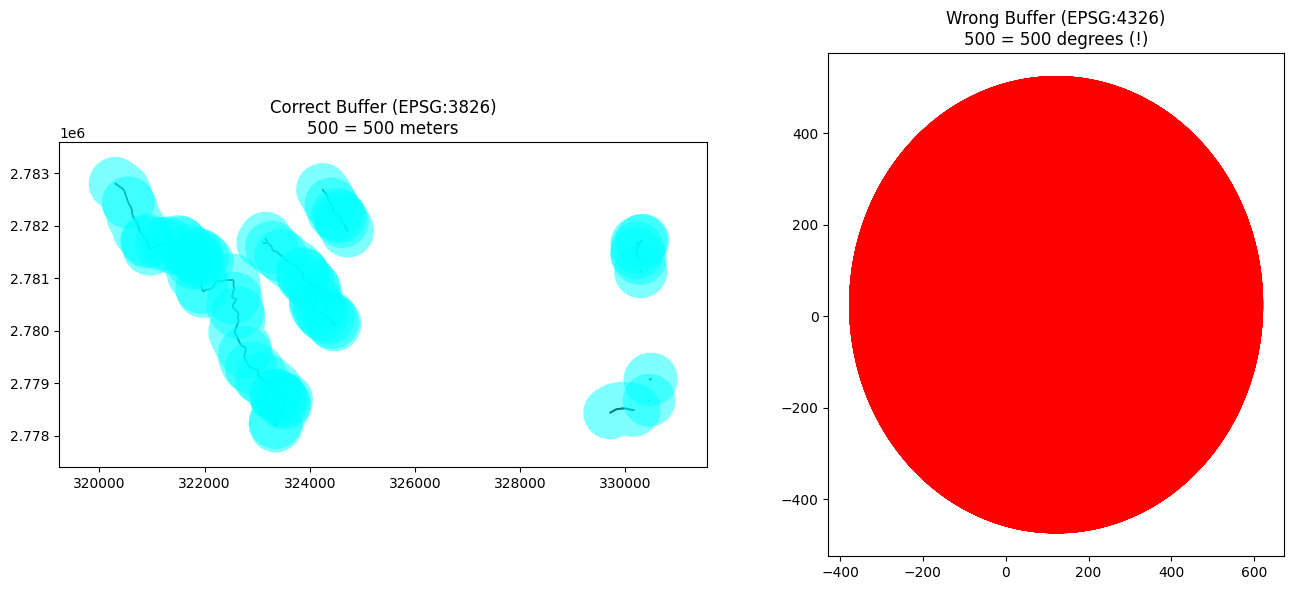

In [30]:
# Paste AI-generated code below, then run this cell
import matplotlib.pyplot as plt
import geopandas as gpd

# Use only first 50 rows for speed
rivers50 = rivers.head(50)
rivers4326_50 = rivers_4326.head(50)

buffer_correct50 = buffer_correct.head(50)
buffer_wrong50 = buffer_wrong.head(50)

# Create subplot
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# LEFT — correct buffer
rivers50.plot(ax=ax[0], color='blue', edgecolor='black')
buffer_correct50.plot(ax=ax[0], color='cyan', alpha=0.5)

ax[0].set_title(
    "Correct Buffer (EPSG:3826)\n"
    "500 = 500 meters"
)

# RIGHT — wrong buffer
rivers4326_50.plot(ax=ax[1], color='blue', edgecolor='black')
buffer_wrong50.plot(ax=ax[1], color='red', alpha=0.5)

ax[1].set_title(
    "Wrong Buffer (EPSG:4326)\n"
    "500 = 500 degrees (!)"
)

plt.tight_layout()
plt.show()

### Step 6: Save correct buffer for Lab 2

**Prompt to give AI:**
```
Save the correct river buffer (buffer_correct, EPSG:3826) as a GeoDataFrame,
then export to "data/river_buffer_500m.geojson".
Also create a folium interactive map showing:
- River polygons in blue
- 500m buffer in cyan (semi-transparent)
Use only first 100 rows for speed. Convert to EPSG:4326 for folium.
Save the map to "outputs/lab1_river_buffer_map.html" using m.save().
Create the "data" and "outputs" folders first with os.makedirs(..., exist_ok=True).
```

> Open `outputs/lab1_river_buffer_map.html` in browser if the map doesn't render inline.

- 建立 data、outputs 資料夾
- 將 buffer_correct (EPSG:3826) 存成 GeoJSON
- 取 前100筆資料
- 轉成 EPSG:4326 給 folium 使用
- 建立互動地圖並輸出 HTML

In [31]:
# Paste AI-generated code below, then run this cell

import os
import folium

# 1️⃣ 建立資料夾
os.makedirs("data", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

# 2️⃣ 只使用前100筆資料
rivers100 = rivers.head(100)
buffer100 = buffer_correct.head(100)

# 3️⃣ 建立 buffer GeoDataFrame (EPSG:3826)
buffer_gdf = gpd.GeoDataFrame(
    rivers100.drop(columns="geometry"),
    geometry=buffer100,
    crs="EPSG:3826"
)

# 4️⃣ 輸出 GeoJSON
buffer_gdf.to_file(
    "data/river_buffer_500m.geojson",
    driver="GeoJSON"
)

# 5️⃣ folium 需要 EPSG:4326
rivers4326 = rivers100.to_crs(epsg=4326)
buffer4326 = buffer_gdf.to_crs(epsg=4326)

# 6️⃣ 建立地圖中心
center = rivers4326.geometry.unary_union.centroid
m = folium.Map(
    location=[center.y, center.x],
    zoom_start=10
)

# 7️⃣ 加入 river polygons (blue)
folium.GeoJson(
    rivers4326,
    name="Rivers",
    style_function=lambda x: {
        "color": "blue",
        "weight": 1,
        "fillOpacity": 0.3
    }
).add_to(m)

# 8️⃣ 加入 buffer (cyan)
folium.GeoJson(
    buffer4326,
    name="500m Buffer",
    style_function=lambda x: {
        "color": "cyan",
        "fillColor": "cyan",
        "fillOpacity": 0.4
    }
).add_to(m)

folium.LayerControl().add_to(m)

# 9️⃣ 儲存地圖
m.save("outputs/lab1_river_buffer_map.html")

print("GeoJSON saved to: data/river_buffer_500m.geojson")
print("Map saved to: outputs/lab1_river_buffer_map.html")

GeoJSON saved to: data/river_buffer_500m.geojson
Map saved to: outputs/lab1_river_buffer_map.html


---
# Lab 2 — Spatial Join: Shelter Flood Risk (30 min)
*Slide 20 · Build on Lab 1's river buffer to find at-risk shelters*

Use the **500m river buffer** from Lab 1 and combine it with **shelter data** to identify which shelters are in the flood risk zone.

### Step 1: Load shelter data

**Prompt to give AI:**
```
Using osmnx (import as ox), download all shelter features in Da'an District, Taipei, Taiwan
from OpenStreetMap using tags={'amenity': 'shelter'}.
Convert the result to a GeoDataFrame, print the count and geometry types.
If osmnx fails, create 30 fake shelters instead:
- Random coordinates around Taipei (lon 121.49~121.58, lat 25.01~25.08)
- Columns: shelter_id, name, capacity (random 50~500)
- CRS: EPSG:4326, use np.random.seed(114)
Important: use Da'an DISTRICT, not all of Taipei — querying all of Taipei is too slow.
```

In [34]:
# Paste AI-generated code below, then run this cell
import numpy as np
import osmnx as ox
import geopandas as gpd
from shapely.geometry import Point

try:
    # 1️⃣ Query shelters from OpenStreetMap
    tags = {"amenity": "shelter"}

    shelters = ox.features_from_place(
        "Da'an District, Taipei, Taiwan",
        tags=tags
    )

    shelters_gdf = gpd.GeoDataFrame(shelters)

    print("Shelters downloaded from OSM")
    print("Count:", len(shelters_gdf))
    print("Geometry types:", shelters_gdf.geom_type.unique())

except Exception as e:

    print("OSMnx download failed, generating fake shelters...")
    print(e)

    # 2️⃣ Create fake shelters
    np.random.seed(114)

    n = 30
    lons = np.random.uniform(121.49, 121.58, n)
    lats = np.random.uniform(25.01, 25.08, n)

    geometries = [Point(lon, lat) for lon, lat in zip(lons, lats)]

    shelters_gdf = gpd.GeoDataFrame(
        {
            "shelter_id": range(1, n + 1),
            "name": [f"Shelter_{i}" for i in range(1, n + 1)],
            "capacity": np.random.randint(50, 501, n)
        },
        geometry=geometries,
        crs="EPSG:4326"
    )

    print("Fake shelters created")
    print("Count:", len(shelters_gdf))
    print("Geometry types:", shelters_gdf.geom_type.unique())

# preview
shelters_gdf.head()

Shelters downloaded from OSM
Count: 50
Geometry types: ['Point' 'Polygon']


amenity    shelter_type                    geometry  \
element_type osmid                                                             
node         2703799743  shelter  picnic_shelter  POINT (121.54279 25.03464)   
             3216077274  shelter             NaN  POINT (121.52793 25.03193)   
             4213847986  shelter             NaN  POINT (121.53892 25.00972)   
             4524864518  shelter             NaN  POINT (121.54100 25.02270)   
             4524864519  shelter             NaN  POINT (121.54085 25.02251)   

                        name start_date nodes access building bench  bin  \
element_type osmid                                                         
node         2703799743  NaN        NaN   NaN    NaN      NaN   NaN  NaN   
             3216077274  NaN        NaN   NaN    NaN      NaN   NaN  NaN   
             4213847986  NaN        NaN   NaN    NaN      NaN   NaN  NaN   
             4524864518  NaN        NaN   NaN    NaN      NaN   NaN  NaN   
             4524864519  NaN        NaN   NaN    NaN      NaN   NaN  NaN   

                        check_date  lit lockable wikimedia_commons layer  \
element_type osmid                                                         
node         2703799743        NaN  NaN      NaN               NaN   NaN   
             3216077274        NaN  NaN      NaN               NaN   NaN   
             4213847986        NaN  NaN      NaN               NaN   NaN   
             4524864518        NaN  NaN      NaN               NaN   NaN   
             4524864519        NaN  NaN      NaN               NaN   NaN   

                        building:levels  ref  
element_type osmid                            
node         2703799743             NaN  NaN  
             3216077274             NaN  NaN  
             4213847986             NaN  NaN  
             4524864518             NaN  NaN  
             4524864519             NaN  NaN

### Step 2: Verify CRS alignment

**Before sjoin, ALWAYS check:** Do the two GeoDataFrames share the same CRS?

In [35]:
# Lab 1 buffer is in EPSG:3826 — what about shelter data?
buffer_gdf = gpd.GeoDataFrame(geometry=buffer_correct, crs='EPSG:3826')
print('Buffer CRS  :', buffer_gdf.crs)
print('Shelter CRS :', shelters.crs)      # variable name from Step 1

# Reproject shelters to EPSG:3826 if needed
shelters_3826 = shelters.to_crs(epsg=3826)  # Which EPSG should match the buffer?
print('\nAfter reprojection:', shelters_3826.crs)

Buffer CRS  : EPSG:3826
Shelter CRS : epsg:4326

After reprojection: EPSG:3826


### Step 3: Spatial Join

**Prompt to give AI:**
```
Run gpd.sjoin() to find which shelters (shelters_3826, EPSG:3826) fall WITHIN
the river 500m buffer zone (buffer_gdf, EPSG:3826).
Print how many shelters are at risk vs. total.
If the data has a capacity column, also sum the capacity of at-risk shelters.
```

**After running, verify:**
- Is the result count ≤ total shelter count?
- Did the AI check for one-to-many join issues?

In [40]:
# Paste AI-generated code below, then run this cell
import geopandas as gpd

# Spatial join: shelters within river buffer
at_risk = gpd.sjoin(
    shelters_3826,
    buffer_gdf,
    predicate="within",
    how="inner"
)

# Count shelters
total_shelters = len(shelters_3826)
risk_shelters = len(at_risk)

print(f"Shelters at risk: {risk_shelters} / {total_shelters}")

# If capacity column exists, sum capacity
if "capacity" in shelters_3826.columns:
    total_capacity = at_risk["capacity"].sum()
    print(f"Total capacity at risk: {total_capacity}")

Shelters at risk: 33 / 50


### Step 4: Check for duplicates

**Prompt to give AI:**
```
Check if the sjoin result has more rows than the original shelters.
If yes, a shelter matched multiple buffer zones (one-to-many).
Show which shelters are duplicated and deduplicate using drop_duplicates.
```

In [ ]:
buffer_union = buffer_gdf.dissolve()
at_risk_dissolved = gpd.sjoin(shelters_3826, buffer_union, predicate="within")

original_count = len(at_risk)
dissolved_count = len(at_risk_dissolved)

print(f"Original shelters: {original_count}")
print(f"Join result rows: {dissolved_count}")

if dissolved_count < original_count:
    print("⚠ Some shelters matched multiple buffer zones (one-to-many).")
else:
    print("No duplicate matches.")

Original shelters: 33
Join result rows: 6
⚠ Some shelters matched multiple buffer zones (one-to-many).


### Step 5: Visualize — Red = at risk, Green = safe

**Prompt to give AI:**
```
Create an interactive map using .explore() or folium showing:
- Light gray background: townships (filter 臺北市 from the "townships" GeoDataFrame)
- Blue: river polygons (use rivers variable, first 100 rows)
- Cyan semi-transparent: 500m buffer zone (first 100 rows)
- Red dots: shelters INSIDE the buffer (at risk)
- Green dots: shelters OUTSIDE the buffer (safe)
Remember to reproject everything to EPSG:4326 for the web map.
Center the map on Taipei (lat=25.05, lon=121.55).
Save the map to "outputs/lab2_shelter_risk_map.html" using m.save().
```

> Open `outputs/lab2_shelter_risk_map.html` in browser if the map doesn't render inline.

**After running, verify:**
- Are the red dots actually near rivers?
- Are the green dots clearly outside the buffer zone?

In [45]:
# Paste AI-generated code below, then run this cell
import os
import geopandas as gpd
import folium

# 確保輸出資料夾存在
os.makedirs("outputs", exist_ok=True)

# 1️⃣ 選出臺北市行政區
taipei_townships = townships[townships["COUNTYNAME"] == "臺北市"]

# 2️⃣ 只使用前100筆河流與buffer
rivers100 = rivers.head(100)
buffer100 = buffer_union.head(100)

# 3️⃣ CRS轉換（folium需要EPSG:4326）
townships4326 = taipei_townships.to_crs(4326)
rivers4326 = rivers100.to_crs(4326)
buffer4326 = buffer100.to_crs(4326)
shelters4326 = shelters_3826.to_crs(4326)
at_risk4326 = at_risk_dissolved.to_crs(4326)

# 4️⃣ 找出安全 shelters
safe_shelters = shelters4326.loc[
    ~shelters4326.index.isin(at_risk4326.index)
]

# 5️⃣ 建立地圖
m = folium.Map(location=[25.05, 121.55], zoom_start=12)

# 6️⃣ townships (背景)
folium.GeoJson(
    townships4326,
    name="Taipei Townships",
    style_function=lambda x: {
        "color": "black",
        "weight": 1,
        "fillColor": "lightgray",
        "fillOpacity": 0.3
    }
).add_to(m)

# 7️⃣ rivers
folium.GeoJson(
    rivers4326,
    name="Rivers",
    style_function=lambda x: {
        "color": "blue",
        "weight": 2
    }
).add_to(m)

# 8️⃣ buffer zone
folium.GeoJson(
    buffer4326,
    name="500m River Buffer",
    style_function=lambda x: {
        "color": "cyan",
        "fillColor": "cyan",
        "fillOpacity": 0.4
    }
).add_to(m)

# 9️⃣ shelters at risk (red)
for _, row in at_risk4326.iterrows():
    pt = row.geometry.centroid

    folium.CircleMarker(
        location=[pt.y, pt.x],
        radius=5,
        color="red",
        fill=True,
        fill_color="red",
        fill_opacity=0.9,
        popup=f"Shelter {row.get('shelter_id', '')}"
    ).add_to(m)

# 🔟 shelters safe (green)
for _, row in safe_shelters.iterrows():
    pt = row.geometry.centroid

    folium.CircleMarker(
        location=[pt.y, pt.x],
        radius=5,
        color="green",
        fill=True,
        fill_color="green",
        fill_opacity=0.9
    ).add_to(m)

# 圖層控制
folium.LayerControl().add_to(m)

# 1️⃣1️⃣ 儲存地圖
m.save("outputs/lab2_shelter_risk_map.html")

print("Map saved to outputs/lab2_shelter_risk_map.html")

Map saved to outputs/lab2_shelter_risk_map.html


---
## Reflection

Answer these questions in your own words:

**1.** In Lab 1, the river data was already in EPSG:3826 (meters). We had to deliberately convert to 4326 to see the trap. In real work, how would you know if your data's CRS is safe for buffering?  
> Your answer: 第一步要先檢查Projected CRS（投影座標系統）

**2.** In Lab 2, what is the key difference between `gpd.sjoin()` and Excel's VLOOKUP? Why can't VLOOKUP answer "which shelters are near a river"?  
> Your answer: Excel 的 VLOOKUP 是：依照「相同欄位值」做匹配，只理解 屬性資料 (attributes)無法處理空間關係。而 GeoPandas sjoin 是依照「空間關係」做匹配。

**3.** After today's exercises, what would you check FIRST when reviewing GeoPandas code that AI generates?  
> Your answer: 
1️⃣ CRS 是否正確
'gdf.crs'

2️⃣ 空間運算前是否轉 CRS
'to_crs()'

3️⃣ geometry type
'gdf.geom_type.unique()'

4️⃣ 是否有 one-to-many spatial join
sjoin row count > original

### Lab 輸出結果

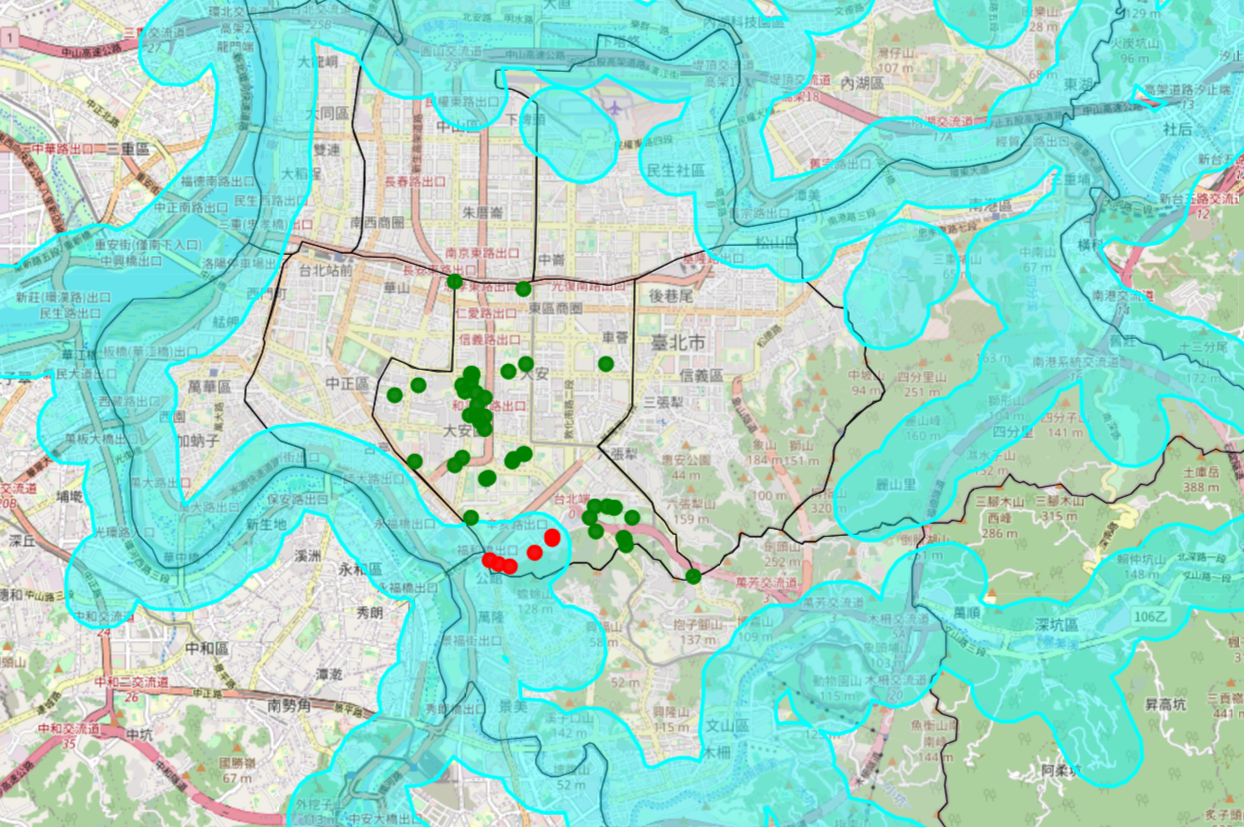